In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12n.pt

In [ ]:
!pip install ultralytics supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.2/382.2 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 10.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov12n.pt')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
!nvidia-smi

Tue Sep 15 07:41:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Training

In [ ]:
# Copy the dataset ZIP to the current working directory
!scp -r "/content/drive/MyDrive/vehicle-detection.v2i.yolov12.zip" .

In [ ]:
!unzip "/content/vehicle-detection.v2i.yolov12.zip"

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/Screenshot-2025-04-02-145122_png.rf.2a7a1f96b139c5b5b52893155f05b7cb.txt  
  inflating: train/labels/Screen-Shot-2025-04-08-at-8_53_45-AM_png.rf.515dddb9f9a747848f5b5332b1057619.txt  
  inflating: train/labels/976_0_jpg.rf.d412c1f39451b91c9218ea2d48f6746a.txt  
  inflating: train/labels/tyoto_minivan1349_png.rf.9ec81efae7353a29c2d8911dff667a64.txt  
  inflating: train/labels/101_1184_jpg.rf.22c63dc2d2fef871afbf9a0f41bafe1e.txt  
  inflating: train/labels/Screenshot-2025-03-31-213028_png.rf.ea8a4863437768f1651950e0832c177e.txt  
  inflating: train/labels/-526B0491-0C42-4F0F-A201-ECFD6ED3DD6E-png_jpg.rf.1b9b061139ddabdd29a1732fb2162e04.txt  
  inflating: train/labels/-11F0AF93-D3D0-4415-A4A0-B3430EA0886B-png_jpg.rf.dff3c7448e0d0c806090374626ba1051.txt  
  inflating: train/labels/bus-216-_jpg.rf.62ddfb19feabfe7ccad47233782ee917.txt  
  inflating: train/labels/bus-99-_jpg.rf.d1b50e6e6c00200f657ca5a233249728.txt  


In [ ]:
results = model.train(
        data='/content/data.yaml', # Using 20 epochs for faster training
        epochs=50,
        batch=16,
        imgsz=640,
        exist_ok=True,
        patience=10,              # Early stopping if no improvement for 5 epochs
        save_period=5,           # Save checkpoints every 5 epochs
        val=True,                # Ensure validation is performed
        verbose=True,            # Show detailed output during training
)

Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize

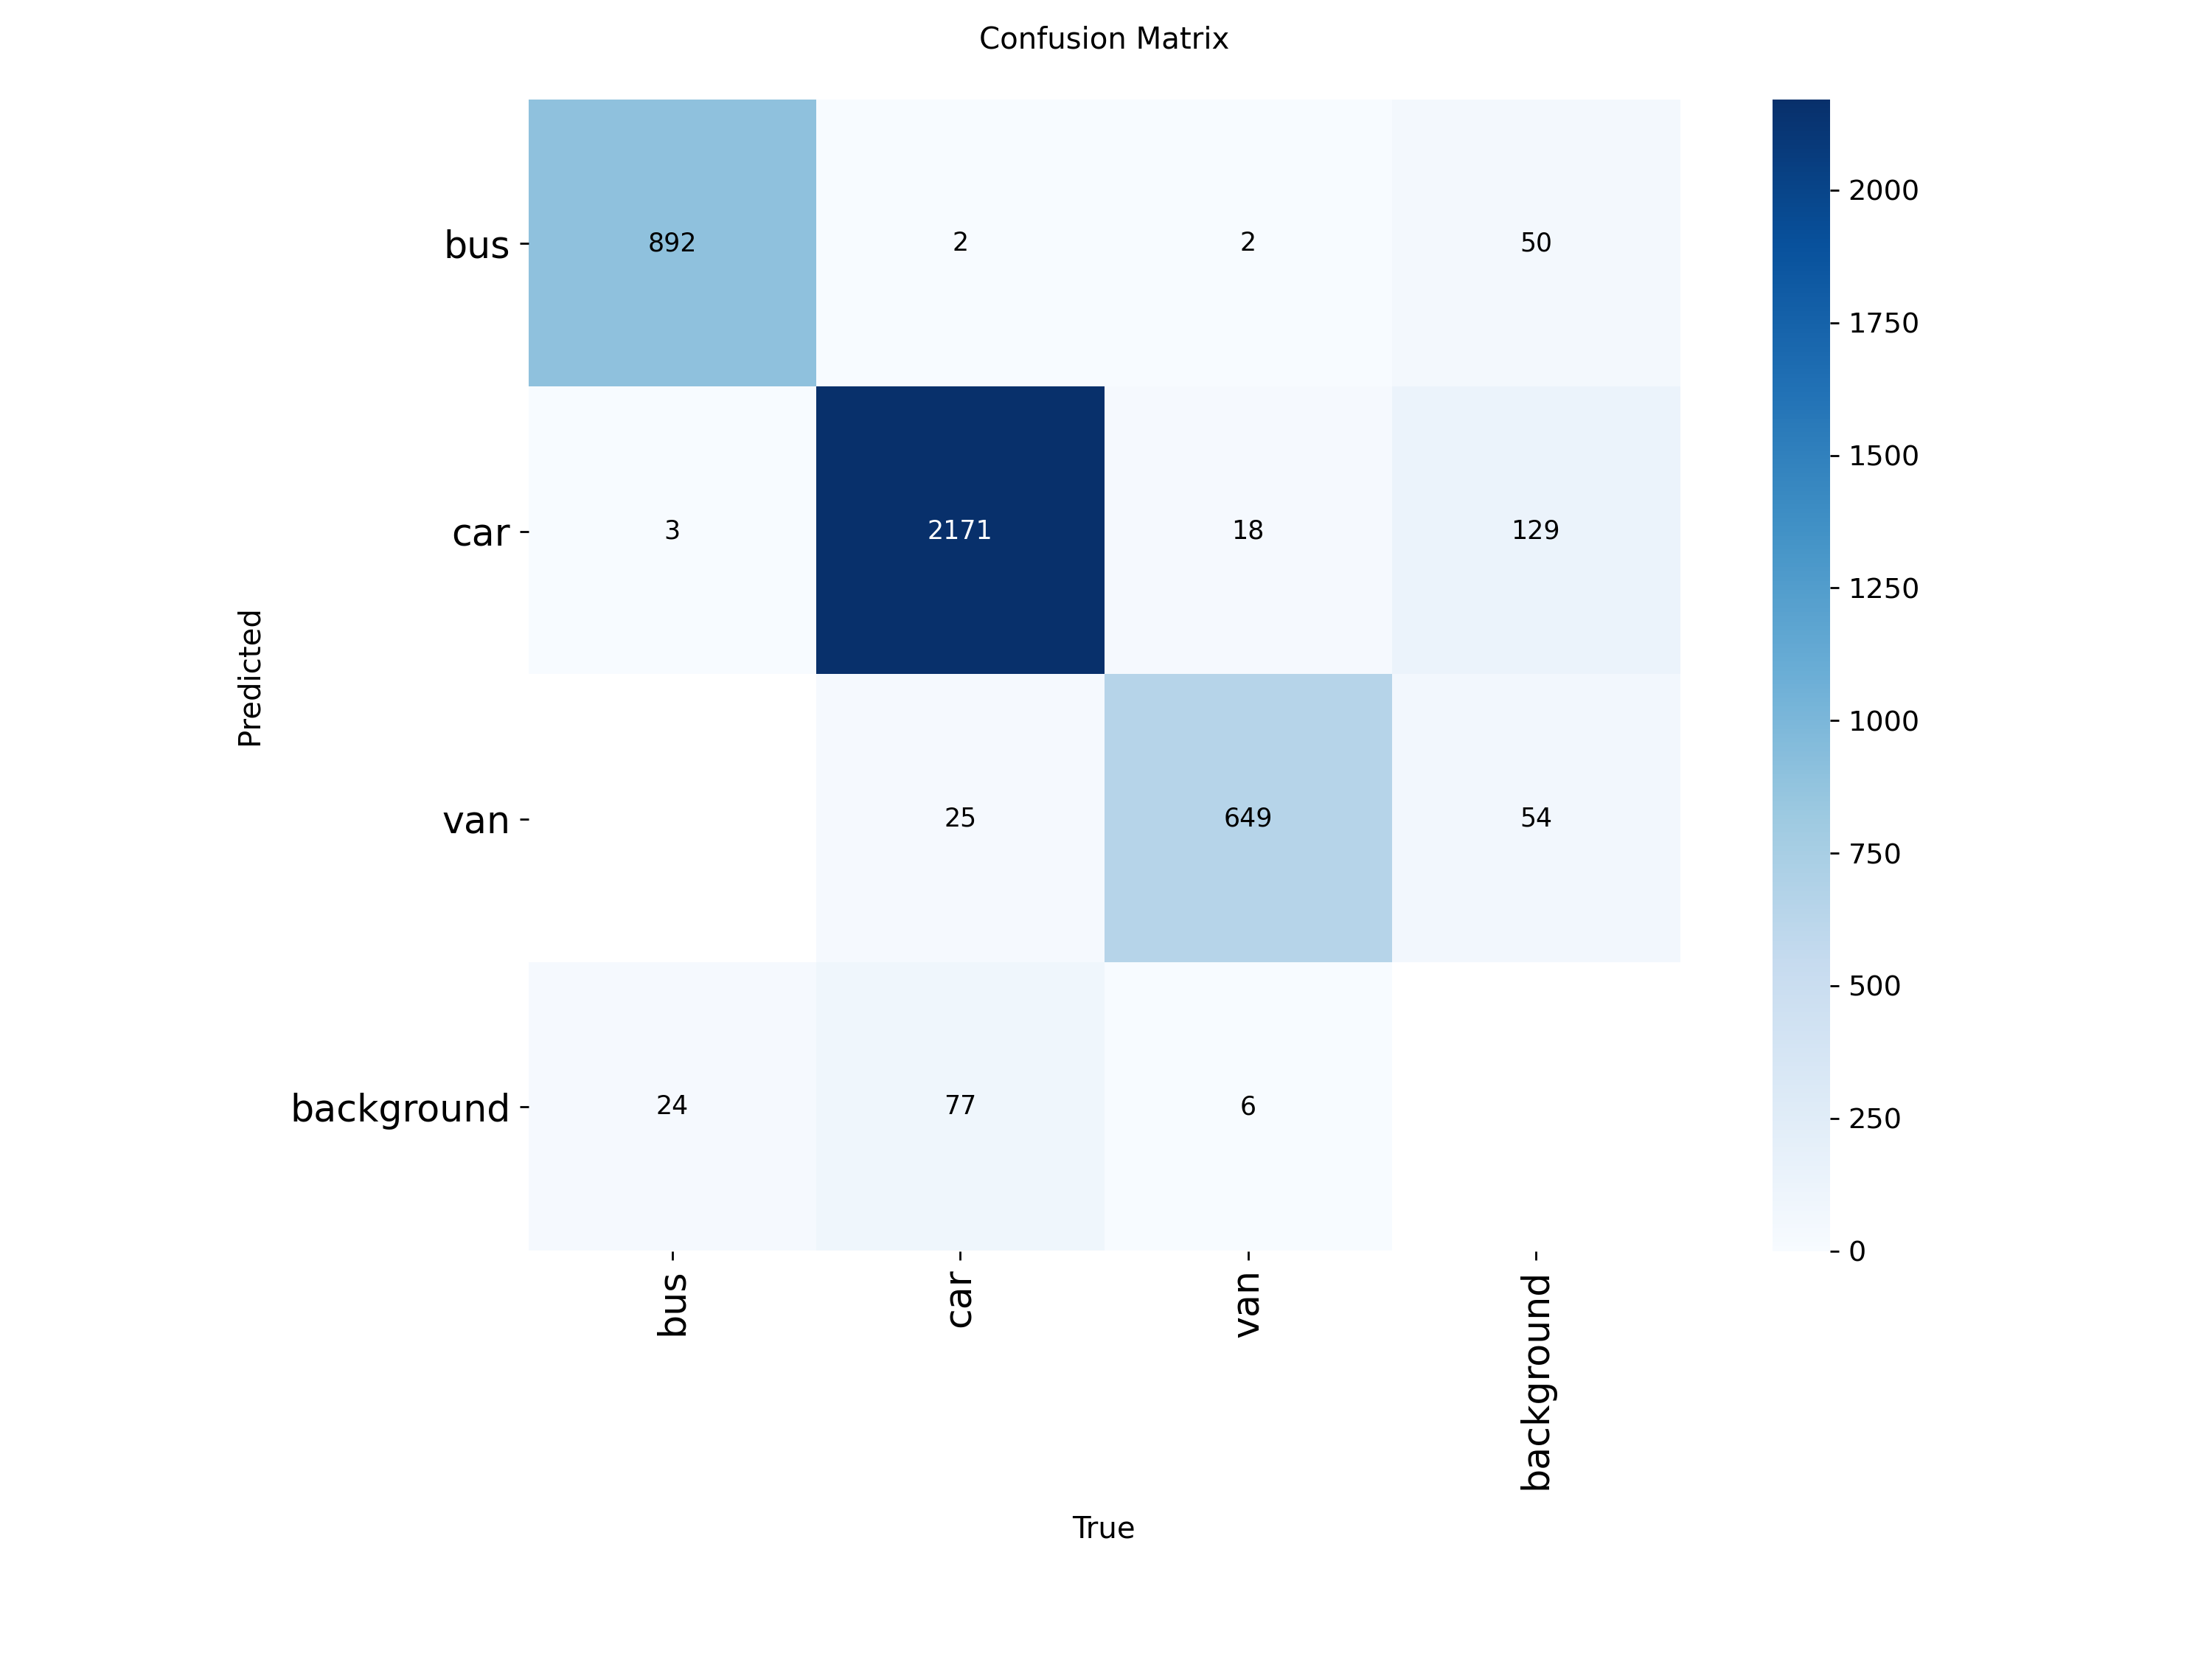

In [ ]:
from IPython.display import Image

Image(filename='content/runs/detect/train/confusion_matrix.png', width=1000)

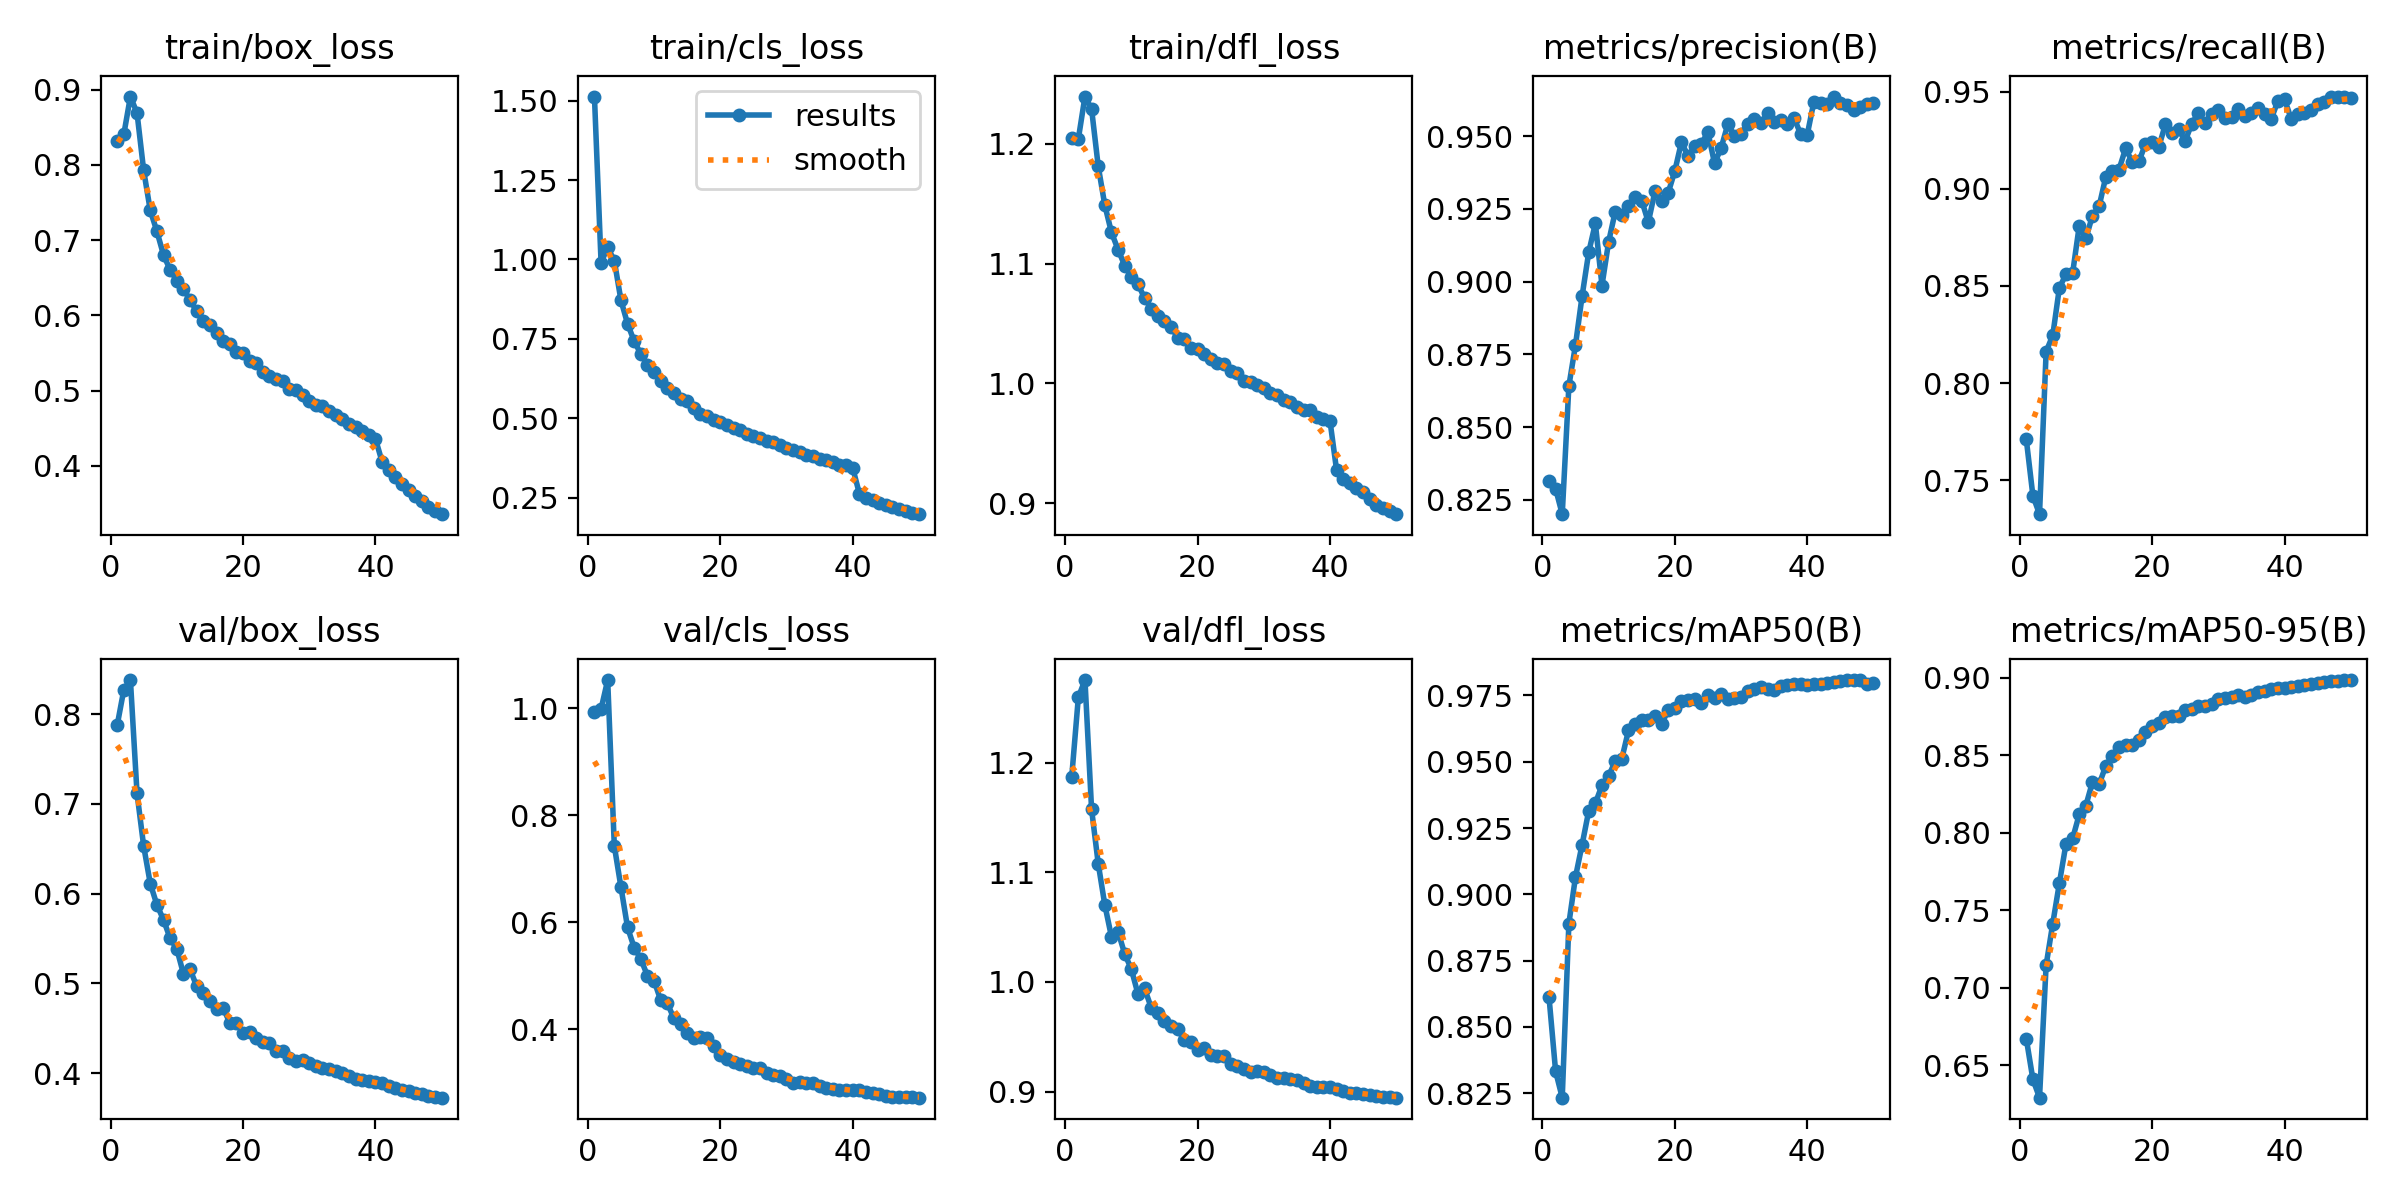

In [ ]:
from IPython.display import Image

Image(filename='content/runs/detect/train/results.png', width=1000)

In [ ]:
from supervision.metrics import MeanAveragePrecision

model = YOLO('best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [ ]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.875858339913214
mAP 50 0.9425129768478595
mAP 75 0.9245068149598125


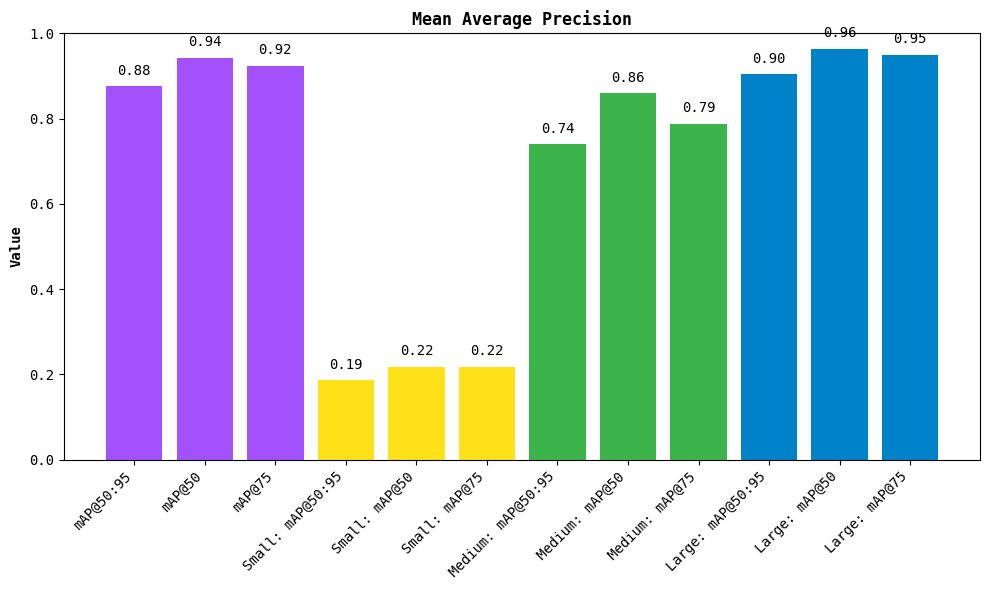

In [ ]:
map.plot()

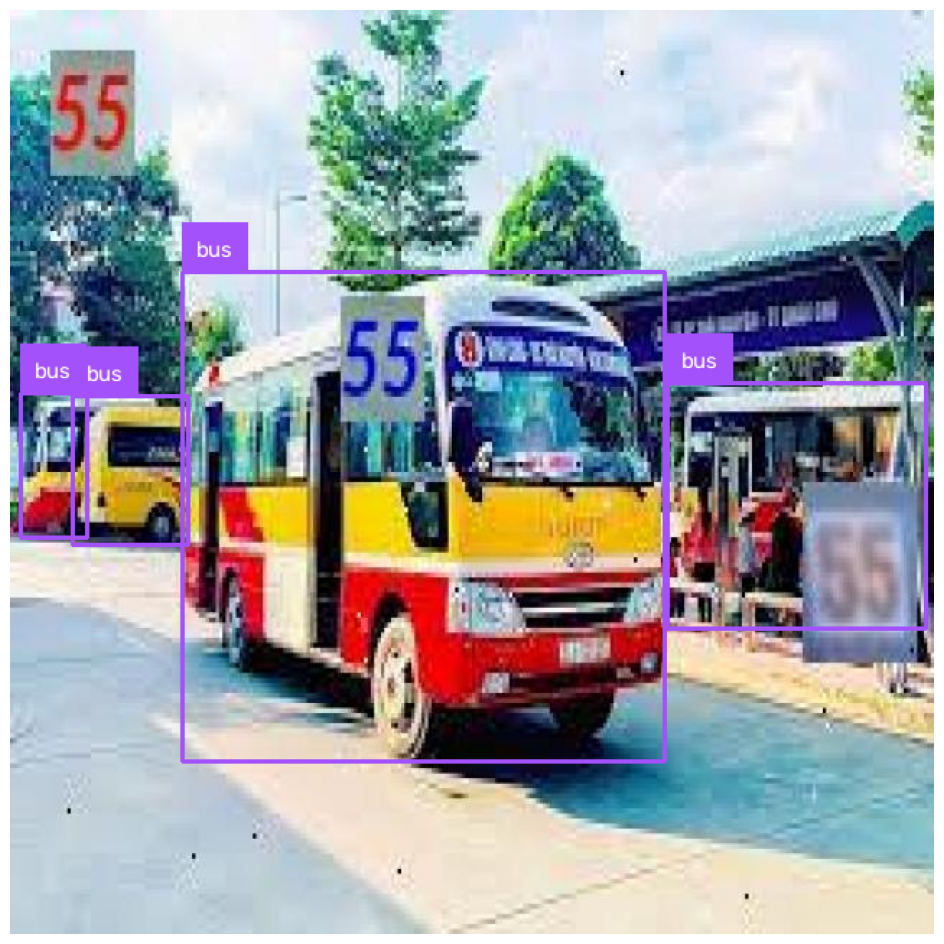

In [ ]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)